In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
import io

def read_horizons_csv(filename):
    with open(filename, 'r') as f:
        lines = f.readlines()

    # 1. Find the markers and the header line
    # Usually, the column names are on the line before the '****************' that precedes $$SOE
    # For this specific file, the names are at line index 73
    soe_idx = next(i for i, line in enumerate(lines) if "$$SOE" in line)
    eoe_idx = next(i for i, line in enumerate(lines) if "$$EOE" in line)
    
    # Extract the header names (found just above the data)
    header_line = lines[soe_idx - 2].strip()
    columns = [col.strip() for col in header_line.split(',')]
    
    # Handle the "unnamed" flag columns (N, A, m, etc.)
    columns = [c if c else f"Flag_{i}" for i, c in enumerate(columns)]

    # 2. Extract only the data lines
    data_lines = lines[soe_idx + 1 : eoe_idx]
    
    # 3. Load into Pandas
    df = pd.read_csv(io.StringIO("".join(data_lines)), names=columns, header=None)
    return df

# Usage
df = read_horizons_csv('horizons_results_2001_EC_csv.txt')
print(df.head())

print(df[['Date_________JDUT', 'r', 'delta']].head())

   Date_________JDUT Flag_1 Flag_2   R.A._(ICRF)   DEC__(ICRF)  dRA*cosD  \
0       2.461092e+06      N      m   15 44 14.20   -22 16 40.3  -1063.34   
1       2.461092e+06      N      m   15 44 01.44   -22 16 02.2  -1063.37   
2       2.461092e+06      A      m   15 43 48.68   -22 15 24.1  -1063.44   
3       2.461092e+06      A      m   15 43 35.92   -22 14 46.0  -1063.56   
4       2.461092e+06      A      m   15 43 23.15   -22 14 07.9  -1063.71   

   d(DEC)/dt    a-mass   mag_ex   APmag    S-brt         r       rdot  \
0   226.3277      n.a.     n.a.  16.171     n.a.  0.995355  21.873548   
1   226.2696      n.a.     n.a.  16.169     n.a.  0.995443  21.873835   
2   226.2193      n.a.     n.a.  16.167     n.a.  0.995531  21.874121   
3   226.1773      n.a.     n.a.  16.166     n.a.  0.995618  21.874407   
4   226.1446      n.a.     n.a.  16.164     n.a.  0.995706  21.874693   

      delta    deldot    S-T-O  T-O-M  MN_Illu%  Flag_18  
0  0.083735  3.184396  83.0578  122.8    7.03

In [3]:
dates = df["Date_________JDUT"].astype(float).to_numpy()

dates -= 2400000


In [32]:
night = '26_03_01_a/'

df_data = pd.read_csv(
            night + 'pipelineout_datasubset.dat', sep="\t", comment="#",
            names=["index", "Label", "J.D.-2400000", "rel_flux_T1", "rel_flux_err_T1",
                   "AIRMASS", "Source-Sky_T1", "Source_Error_T1"])

print(df_data['J.D.-2400000'].to_numpy())

dates_observ = df_data['J.D.-2400000'].to_numpy()

[61101.657971 61101.658447 61101.65893  61101.659409 61101.659908
 61101.660384 61101.660864 61101.661348 61101.661825 61101.662325
 61101.662813 61101.663311 61101.66381  61101.664287 61101.664792
 61101.66527  61101.665748 61101.666255 61101.666734 61101.667212
 61101.667717 61101.668216 61101.668693 61101.66917  61101.669671
 61101.67017  61101.670649 61101.671148 61101.671627 61101.672106
 61101.672584 61101.673083 61101.673581 61101.67408  61101.674587
 61101.675086 61101.675562 61101.676061 61101.676561 61101.67706
 61101.677558 61101.678062 61101.678541 61101.679041 61101.679538
 61101.680037 61101.680535 61101.681033 61101.681539 61101.682038
 61101.682515 61101.683013 61101.683492 61101.68397  61101.684469
 61101.684951 61101.685449 61101.685948 61101.686455 61101.686932
 61101.68743  61101.687929 61101.688408 61101.688887 61101.689386
 61101.689894 61101.690372 61101.69087  61101.691371 61101.691849
 61101.692328 61101.692826 61101.693334 61101.693835 61101.694846
 61101.6953

In [33]:
# distance and phase angle correction
d_min = np.min(dates_observ)
d_max = np.max(dates_observ)

mask = (dates >= d_min - 0.5) & (dates <= d_max + 0.5)

new_r = np.interp(dates_observ, dates[mask], df["r"][mask])
new_delta = np.interp(dates_observ, dates[mask], df["delta"][mask])

new_phase_angle = np.interp(dates_observ, dates[mask], df["S-T-O"][mask])

In [34]:
def phi1(angle):
    return np.exp(-3.33*(np.tan(angle/2))**0.63)

def phi2(angle):
    return np.exp(1.87*(np.tan(angle/2))**1.22)


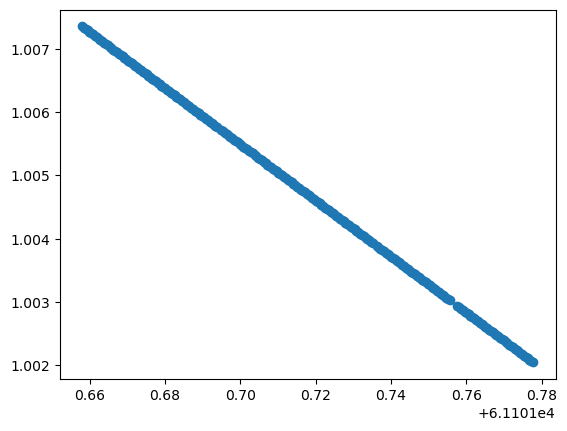

In [35]:
# see page 549-550 and "A three-parameter magnitude phase function for asteroids"

G = 0.15 # typical value when unknown

correction = -2.5*np.log10(new_r*new_delta) + 2.5*np.log10((1 - G)*phi1(new_phase_angle*np.pi/180) + G*phi2(new_phase_angle*np.pi/180))

plt.scatter(dates_observ, correction)
plt.show()

In [36]:
data = np.column_stack((dates_observ, correction))
df_out = pd.DataFrame({
    "Date_________JDUT": dates_observ,
    "mag_correction": correction
})

df_out.to_csv(night + "mag_correction.dat", sep="\t")
